In [46]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

### Loading the CSV file into a pandas DataFrame and saving it into a SQLite database

In [47]:
df = pd.read_csv("142h_ka_as_2025_20260521-183926.csv", skiprows=1)
print(df.head())
conn = sqlite3.connect("municipalities.db")
df.to_sql("municipalities", conn, if_exists="replace", index=False)


     Region                                  Information    1987    1988  \
0  Helsinki                                   Population  490034  489965   
1  Helsinki  Population change from the previous year, %       .     0.0   
2  Helsinki                     Persons aged under 15, %    14.8    15.0   
3  Helsinki                     Persons aged 15 to 64, %    70.8    70.7   
4  Helsinki                   Persons aged 64 or over, %    14.3    14.4   

     1989    1990    1991    1992    1993    1994  ...      2015      2016  \
0  490629  492400  497542  501514  508588  515765  ...  628208.0  635181.0   
1     0.1     0.4     1.0     0.8     1.4     1.4  ...       1.2       1.1   
2    15.0    15.0    15.1    15.3    15.5    15.5  ...      14.0      14.1   
3    70.6    70.6    70.6    70.5    70.5    70.5  ...      69.4      69.2   
4    14.4    14.4    14.3    14.2    14.1    14.0  ...      16.6      16.7   

       2017      2018      2019      2020      2021      2022      2023  \

27

## 3 different SQL queries

#### Population growth in Helsinki between 1994 and 2024 (30 year period)

In [48]:
query = """
SELECT Region, Information, "1994", "2024", ("2024" - "1994") AS Growth
FROM municipalities
WHERE Information = 'Population'
"""

pd.read_sql_query(query, conn)

,Region,Information,1994,2024,Growth
0,Helsinki,Population,515765,684018,168253


We can see that the population has increased by roughly 170k.

### Foreign citizens 1987 VS 2024

In [49]:
query = """
SELECT Region, Information, "1987", "2024", ("2024" - "1987") AS 'Increase (percentage points)' 
FROM municipalities
WHERE Information = 'Foreign citizens, %'
"""

pd.read_sql_query(query, conn)

,Region,Information,1987,2024,Increase (percentage points)
0,Helsinki,"Foreign citizens, %",0.9,12.3,11.4


The percentage of foreign citizens in Helsinki increased from 0.9 to 12.3 (11.4 percentage points) between 1987 and 2024.

### Share of unemployed persons in the labour force 1987 VS 2024

In [50]:
query = """
SELECT Region, Information, "1987", "2024", (("2024" - "1987") / "1987") * 100 AS 'Increase, %'
FROM municipalities
WHERE Information = 'Share of unemployed persons in the labour force, %'
"""

pd.read_sql_query(query, conn)

,Region,Information,1987,2024,"Increase, %"
0,Helsinki,Share of unemployed persons in the labour forc...,2.3,12.1,426.086957


The unemployment rate has increased by about 426% between the years 1987 and 2024.

## Correlation

I chose two columns that I think are correlated: "Employment rate of persons aged 20 to 64, %" and "Share of unemployed persons in the labour force, %".

In [51]:
employment = df[df["Information"] == "Employment rate of persons aged 20 to 64, %"]
employment = employment.iloc[0, 2:]
employment = pd.to_numeric(employment)

unemployed = df[df["Information"] == "Share of unemployed persons in the labour force, %"]
unemployed = unemployed.iloc[0, 2:]
unemployed = pd.to_numeric(unemployed)

corr = unemployed.corr(employment)
print(corr)

-0.9510964217906732


The correlation between these two columns was -0.95, which shows a strong negatative correlation.

## Matplotlib plots

### Stacked Bar Chart: Population by Age 2024

Text(0.5, 1.0, 'Helsinki Age Distribution 2024')

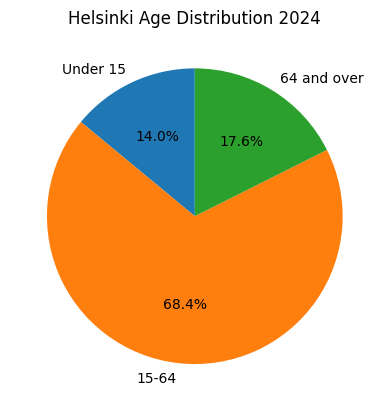

In [116]:
under_15_query = """
SELECT "2024", "Information"
FROM municipalities
WHERE Information = 'Persons aged under 15, %'
"""

between_query = """
SELECT "2024", "Information"
FROM municipalities
WHERE Information = 'Persons aged 15 to 64, %'
"""

over_64_query = """
SELECT "2024", "Information"
FROM municipalities
WHERE Information = 'Persons aged 64 or over, %'
"""

under_15 = pd.read_sql_query(under_15_query, conn).iloc[0, 0]
between = pd.read_sql_query(between_query, conn).iloc[0, 0]
over_64 = pd.read_sql_query(over_64_query, conn).iloc[0, 0]

sizes = [under_15, between, over_64]
sizes = sorted(sizes)


labels = ['Under 15', '15-64', '64 and over']
sizes = [under_15, between, over_64]

plt.pie(sizes, labels=labels, autopct='%.1f%%', startangle=90)
plt.title('Helsinki Age Distribution 2024')

